### Create datasets

In [3]:
%run prep.py -d flights

### Set up your local cluster

In [60]:
from dask.distributed import Client
client = Client(n_workers=4)
client

C:\Users\Andriy\analytics\labs\.venv\Lib\site-packages\distributed\node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 54837 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:54837/status,
Dashboard: http://127.0.0.1:54837/status,Workers: 4
Total threads: 4,Total memory: 7.70 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:54842,Workers: 0
Dashboard: http://127.0.0.1:54837/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:54863,Total threads: 1
Dashboard: http://127.0.0.1:54871/status,Memory: 1.93 GiB
Nanny: tcp://127.0.0.1:54845,


2025-10-19 19:02:23,552 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:54863' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('read-fused-c5e50c345bdf061cdeb2bc7d8107b239', 9), ('read-fused-c5e50c345bdf061cdeb2bc7d8107b239', 5)} (stimulus_id='handle-worker-cleanup-1760889743.5497777')
2025-10-19 19:02:23,585 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:54864' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('read-fused-c5e50c345bdf061cdeb2bc7d8107b239', 6), ('read-fused-c5e50c345bdf061cdeb2bc7d8107b239', 1), ('read-fused-c5e50c345bdf061cdeb2bc7d8107b239', 2)} (stimulus_id='handle-worker-cleanup-1760889743.5853982')
2025-10-19 19:02:23,593 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:54861' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('read-fused-c5e50c345bdf061cdeb2bc7d8107b239', 0), ('re

### Reading and working with datasets

In [61]:
import os
import dask

In [62]:
import dask.dataframe as dd

ddf = dd.read_csv(
    os.path.join("data", "nycflights", "*.csv"), parse_dates={"Date": [0, 1, 2]}
)
ddf

C:\Users\Andriy\analytics\labs\.venv\Lib\site-packages\dask\dataframe\io\csv.py:594: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  head = reader(BytesIO(b_sample), nrows=sample_rows, **head_kwargs)


,Date,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,Diverted
npartitions=10,,,,,,,,,,,,,,,,,,,,,
,datetime64[ns],int64,float64,int64,float64,int64,string,int64,float64,float64,int64,float64,float64,float64,string,string,float64,float64,float64,int64,int64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


### Lazy Evaluation

In [63]:
len(ddf)

ValueError: Mismatched dtypes found in `pd.read_csv`/`pd.read_table`.

+----------------+---------+----------+
| Column         | Found   | Expected |
+----------------+---------+----------+
| CRSElapsedTime | float64 | int64    |
| TailNum        | object  | float64  |
+----------------+---------+----------+

The following columns also raised exceptions on conversion:

- TailNum
  ValueError("could not convert string to float: 'N14336'")

Usually this is due to dask's dtype inference failing, and
*may* be fixed by specifying dtypes manually by adding:

dtype={'CRSElapsedTime': 'float64',
       'TailNum': 'object'}

to the call to `read_csv`/`read_table`.

In [64]:
ddf.head()

,Date,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,...,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,Diverted
0,1990-01-01,1,1621.0,1540,1747.0,1701,US,33,NaN,86.0,...,NaN,46.0,41.0,EWR,PIT,319.0,NaN,NaN,0,0
1,1990-01-02,2,1547.0,1540,1700.0,1701,US,33,NaN,73.0,...,NaN,-1.0,7.0,EWR,PIT,319.0,NaN,NaN,0,0
2,1990-01-03,3,1546.0,1540,1710.0,1701,US,33,NaN,84.0,...,NaN,9.0,6.0,EWR,PIT,319.0,NaN,NaN,0,0
3,1990-01-04,4,1542.0,1540,1710.0,1701,US,33,NaN,88.0,...,NaN,9.0,2.0,EWR,PIT,319.0,NaN,NaN,0,0
4,1990-01-05,5,1549.0,1540,1706.0,1701,US,33,NaN,77.0,...,NaN,5.0,9.0,EWR,PIT,319.0,NaN,NaN,0,0


In [65]:
ddf.tail()

ValueError: Mismatched dtypes found in `pd.read_csv`/`pd.read_table`.

+----------------+---------+----------+
| Column         | Found   | Expected |
+----------------+---------+----------+
| CRSElapsedTime | float64 | int64    |
| TailNum        | object  | float64  |
+----------------+---------+----------+

The following columns also raised exceptions on conversion:

- TailNum
  ValueError("could not convert string to float: 'N54711'")

Usually this is due to dask's dtype inference failing, and
*may* be fixed by specifying dtypes manually by adding:

dtype={'CRSElapsedTime': 'float64',
       'TailNum': 'object'}

to the call to `read_csv`/`read_table`.

### Handling conflicting types

In [66]:
ddf = dd.read_csv(
    os.path.join("data", "nycflights", "*.csv"),
    parse_dates={"Date": [0, 1, 2]},
    dtype={"TailNum": str, "CRSElapsedTime": float, "Cancelled": bool},
)

C:\Users\Andriy\analytics\labs\.venv\Lib\site-packages\dask\dataframe\io\csv.py:594: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  head = reader(BytesIO(b_sample), nrows=sample_rows, **head_kwargs)


In [67]:
ddf.tail()  # now works

,Date,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,...,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,Diverted
269176,1999-12-27,1,1645.0,1645,1830.0,1901,UA,1753,N516UA,225.0,...,205.0,-31.0,0.0,LGA,DEN,1619.0,7.0,13.0,False,0
269177,1999-12-28,2,1726.0,1645,1928.0,1901,UA,1753,N504UA,242.0,...,214.0,27.0,41.0,LGA,DEN,1619.0,5.0,23.0,False,0
269178,1999-12-29,3,1646.0,1645,1846.0,1901,UA,1753,N592UA,240.0,...,220.0,-15.0,1.0,LGA,DEN,1619.0,5.0,15.0,False,0
269179,1999-12-30,4,1651.0,1645,1908.0,1901,UA,1753,N575UA,257.0,...,233.0,7.0,6.0,LGA,DEN,1619.0,5.0,19.0,False,0
269180,1999-12-31,5,1642.0,1645,1851.0,1901,UA,1753,N539UA,249.0,...,232.0,-10.0,-3.0,LGA,DEN,1619.0,6.0,11.0,False,0


### Reading from remote storage

In [68]:
#ddf = dd.read_parquet("s3://nyc-tlc/trip data/yellow_tripdata_2012-*.parquet",)

### Computations with dask.dataframe

In [69]:
import pandas as pd

files = os.listdir(os.path.join('data', 'nycflights'))

maxes = []

for file in files:
    df = pd.read_csv(os.path.join('data', 'nycflights', file))
    maxes.append(df.DepDelay.max())
    
final_max = max(maxes)

In [70]:
%%time
result = ddf.DepDelay.max()
result.compute()

CPU times: total: 797 ms
Wall time: 3.89 s


np.float64(1435.0)

# Exercises
### How many rows are in our dataset?

In [71]:
len(ddf)

2611892

In [72]:
size = ddf.shape[0]
print("Загальна кількість рядків:",size.compute())

Загальна кількість рядків: 2611892


### In total, how many non-canceled flights were taken?

In [73]:
result = (ddf["Cancelled"] == 0).sum()
print("Кількість нескасованих рейсів:", result.compute())

Кількість нескасованих рейсів: 2540961


### In total, how many non-canceled flights were taken from each airport?

In [74]:
non_canceled = ddf[ddf['Cancelled'] == 0].groupby('Origin').size()
print("Нескасовані рейси по аеропортах:\n",non_canceled.compute())

Нескасовані рейси по аеропортах:
 Origin
EWR    1139451
JFK     427243
LGA     974267
dtype: int64


### What was the average departure delay from each airport?

In [75]:
result = ddf.groupby("Origin")["DepDelay"].mean()
print("Середня затримка вильоту по аеропортах:\n",result.compute())

Середня затримка вильоту по аеропортах:
 Origin
EWR    10.295469
JFK    10.351299
LGA     7.431142
Name: DepDelay, dtype: float64


### What day of the week has the worst average departure delay?

In [76]:
avg_delay_per_day = ddf.groupby('DayOfWeek')['DepDelay'].mean().compute()
worst_day = avg_delay_per_day.idxmax()
print("День тиждня з найгіршою середньою затримкою:", worst_day)
print("Середня затримка в цей день:", avg_delay_per_day[worst_day])

День тиждня з найгіршою середньою затримкою: 5
Середня затримка в цей день: 11.4766871657754


### Let’s say the distance column is erroneous and you need to add 1 to all values, how would you do this?

In [77]:
ddf.head()

,Date,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,...,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,Diverted
0,1990-01-01,1,1621.0,1540,1747.0,1701,US,33,<NA>,86.0,...,NaN,46.0,41.0,EWR,PIT,319.0,NaN,NaN,False,0
1,1990-01-02,2,1547.0,1540,1700.0,1701,US,33,<NA>,73.0,...,NaN,-1.0,7.0,EWR,PIT,319.0,NaN,NaN,False,0
2,1990-01-03,3,1546.0,1540,1710.0,1701,US,33,<NA>,84.0,...,NaN,9.0,6.0,EWR,PIT,319.0,NaN,NaN,False,0
3,1990-01-04,4,1542.0,1540,1710.0,1701,US,33,<NA>,88.0,...,NaN,9.0,2.0,EWR,PIT,319.0,NaN,NaN,False,0
4,1990-01-05,5,1549.0,1540,1706.0,1701,US,33,<NA>,77.0,...,NaN,5.0,9.0,EWR,PIT,319.0,NaN,NaN,False,0


In [78]:
distance = ddf.Distance.add(1)
print("Перші 5 значень Distance після корекції:\n", distance.compute().head())

Перші 5 значень Distance після корекції:
 0    320.0
1    320.0
2    320.0
3    320.0
4    320.0
Name: Distance, dtype: float64


### Sharing Intermediate Results

In [79]:
non_canceled = ddf[~ddf.Cancelled]
mean_delay = non_canceled.DepDelay.mean()
std_delay = non_canceled.DepDelay.std()

In [111]:
%%time
mean_delay_res = mean_delay.compute()
std_delay_res = std_delay.compute()

CPU times: total: 7.27 s
Wall time: 21.1 s


In [112]:
%%time
mean_delay_res, std_delay_res = dask.compute(mean_delay, std_delay)

CPU times: total: 3.73 s
Wall time: 11 s


In [114]:
#dask.visualize(mean_delay, std_delay, engine="cytoscape")

In [103]:
non_cancelled = ddf[~ddf.Cancelled]
ddf_jfk = non_cancelled[non_cancelled.Origin == "JFK"]

In [109]:
%%time
ddf_jfk.DepDelay.mean().compute()
ddf_jfk.DepDelay.sum().compute()

CPU times: total: 672 ms
Wall time: 1.01 s


np.float64(4422520.0)

In [107]:
ddf_jfk = ddf_jfk.persist()  # returns back control immediately

In [108]:
%%time
ddf_jfk.DepDelay.mean().compute()
ddf_jfk.DepDelay.std().compute()

CPU times: total: 641 ms
Wall time: 1.06 s


np.float64(31.242509798271147)

In [113]:
help(ddf.map_partitions)

Help on method map_partitions in module dask.dataframe.dask_expr._collection:

map_partitions(
    func,
    *args,
    meta=<no_default>,
    enforce_metadata=True,
    transform_divisions=True,
    clear_divisions=False,
    align_dataframes=False,
    parent_meta=None,
    required_columns=None,
    **kwargs
) method of dask.dataframe.dask_expr._collection.DataFrame instance
    Apply a Python function to each partition

    Parameters
    ----------
    func : function
        Function applied to each partition.
    args, kwargs :
        Arguments and keywords to pass to the function. Arguments and
        keywords may contain ``FrameBase`` or regular python objects.
        DataFrame-like args (both dask and pandas) must have the same
        number of partitions as ``self`` or comprise a single partition.
        Key-word arguments, Single-partition arguments, and general
        python-object arguments will be broadcasted to all partitions.
    enforce_metadata : bool, default 

In [115]:
def my_custom_converter(df, multiplier=1):
    return df * multiplier


meta = pd.Series(name="Distance", dtype="float64")

distance_km = ddf.Distance.map_partitions(
    my_custom_converter, multiplier=0.6, meta=meta
)

In [117]:
#distance_km.visualize()

In [118]:
distance_km.head()

0    191.4
1    191.4
2    191.4
3    191.4
4    191.4
Name: Distance, dtype: float64

In [119]:
client.shutdown()

## Dask Arrays

### Create datasets

In [1]:
%run prep.py -d random

- Generating random array data... 

### Start the Client

In [2]:
from dask.distributed import Client

client = Client(n_workers=4)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 7.70 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:57705,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:57724,Total threads: 1
Dashboard: http://127.0.0.1:57728/status,Memory: 1.93 GiB
Nanny: tcp://127.0.0.1:57708,


2025-10-19 20:50:31,130 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:8787', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "C:\Users\Andriy\analytics\labs\.venv\Lib\site-packages\tornado\websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "C:\Users\Andriy\analytics\labs\.venv\Lib\site-packages\tornado\web.py", line 3375, in wrapper
    return method(self, *args, **kwargs)
  File "C:\Users\Andriy\analytics\labs\.venv\Lib\site-packages\bokeh\server\views\ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError: Token is expired. Configure the app with a larger value for --session-token-expiration if necessary
2025-10-19 20:50:35

### Blocked Algorithms in a nutshell

In [3]:
import numpy as np
import dask.array as da

In [5]:
# NumPy array
a_np = np.ones(10)
a_np

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [6]:
a_np_sum = a_np[:5].sum() + a_np[5:].sum()
a_np_sum

np.float64(10.0)

In [7]:
a_da = da.ones(10, chunks=5)
a_da

dask.array<ones_like, shape=(10,), dtype=float64, chunksize=(5,), chunktype=numpy.ndarray>

In [8]:
a_da_sum = a_da.sum()
a_da_sum

dask.array<sum-aggregate, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>

In [9]:
a_da_sum.compute()

np.float64(10.0)

### Performance comparison

In [10]:
%%time
xn = np.random.normal(10, 0.1, size=(3_000, 3_000))
yn = xn.mean(axis=0)
yn

CPU times: total: 391 ms
Wall time: 414 ms


array([ 9.99936244,  9.99907028, 10.00184392, ..., 10.00069845,
       10.00339773,  9.99929646], shape=(3000,))

In [11]:
xd = da.random.normal(10, 0.1, size=(3_000, 3_000), chunks=(300, 300))
xd

dask.array<normal, shape=(3000, 3000), dtype=float64, chunksize=(300, 300), chunktype=numpy.ndarray>

In [12]:
xd.nbytes / 1e9  # Gigabytes of the input processed lazily

0.072

In [13]:
yd = xd.mean(axis=0)
yd

dask.array<mean_agg-aggregate, shape=(3000,), dtype=float64, chunksize=(300,), chunktype=numpy.ndarray>

In [14]:
%%time
xd = da.random.normal(10, 0.1, size=(3_000, 3_000), chunks=(300, 300))
yd = xd.mean(axis=0)
yd.compute()

CPU times: total: 609 ms
Wall time: 2.2 s


array([10.00109862, 10.00246092,  9.99941589, ...,  9.99963313,
       10.00014883,  9.99925047], shape=(3000,))

# Exercise
## What happens if the Dask chunks=(10000,10000)?
## What happens if the Dask chunks=(30,30)?
## For Dask arrays, compute the mean along axis=1 of the sum of the x array and its transpose.

In [15]:
ad = da.random.normal(10, 0.1, size=(3_000, 3_000), chunks=(10000, 10000))
ad

dask.array<normal, shape=(3000, 3000), dtype=float64, chunksize=(3000, 3000), chunktype=numpy.ndarray>

In [16]:
md = da.random.normal(10, 0.1, size=(3_000, 3_000), chunks=(30, 30))
md

dask.array<normal, shape=(3000, 3000), dtype=float64, chunksize=(30, 30), chunktype=numpy.ndarray>

In [18]:
%%time
md = da.random.normal(10, 0.1, size=(3_000, 3_000), chunks=(300, 300))
md1 = (md+md.T).mean(axis=1)
md1.compute()

CPU times: total: 531 ms
Wall time: 886 ms


array([19.99963522, 20.00057727, 19.99997471, ..., 19.9996681 ,
       20.00472465, 20.00218043], shape=(3000,))

### Choosing good chunk sizes

In [19]:
darr = da.random.random((1000, 1000, 100))
darr

dask.array<random_sample, shape=(1000, 1000, 100), dtype=float64, chunksize=(409, 409, 100), chunktype=numpy.ndarray>

In [20]:
darr.chunksize

(409, 409, 100)

In [21]:
darr.chunks

((409, 409, 182), (409, 409, 182), (100,))

In [22]:
darr = darr.rechunk({0: -1, 1: 100, 2: "auto"})

In [23]:
darr.chunksize

(1000, 100, 100)

In [24]:
darr

dask.array<rechunk-merge, shape=(1000, 1000, 100), dtype=float64, chunksize=(1000, 100, 100), chunktype=numpy.ndarray>

In [25]:
darr.chunks

((1000,), (100, 100, 100, 100, 100, 100, 100, 100, 100, 100), (100,))

# Exercise
### What does -1 do when specify as the chunk on a certain axis?
Використати один чанк вздовж цієї осі, який покриває всю довжину осі.
Тобто Dask не ділить цю вісь на менші частини, а створює один великий чанк, що охоплює всю вісь.

In [29]:
x = darr.rechunk({0: -1, 1:-1, 2: -1})
x

dask.array<rechunk-merge, shape=(1000, 1000, 100), dtype=float64, chunksize=(1000, 1000, 100), chunktype=numpy.ndarray>

In [30]:
import zarr

In [31]:
a = da.from_zarr("data/random.zarr")

In [32]:
a

dask.array<from-zarr, shape=(200000000,), dtype=float64, chunksize=(6250000,), chunktype=numpy.ndarray>

In [33]:
%%time
a.mean().compute()

CPU times: total: 625 ms
Wall time: 3.77 s


np.float64(0.4999872037523489)

In [34]:
b = da.from_zarr("data/random_sc.zarr")
b

dask.array<from-zarr, shape=(200000000,), dtype=float64, chunksize=(10000,), chunktype=numpy.ndarray>

In [35]:
%%time
b.mean().compute()

CPU times: total: 1min 7s
Wall time: 2min 52s


np.float64(0.47547713536012487)

# Exercise

### Provide a chunksize when reading b that will improve the time of computation of the mean. Try multiple chunks values and see what happens.


In [38]:
с = b.rechunk(1_000_000)  

In [39]:
%%time
c.mean().compute()

CPU times: total: 27.8 s
Wall time: 47.2 s


np.float64(0.47547713536012487)

In [47]:
import xarray as xr

In [49]:
ds = xr.tutorial.open_dataset(
    "air_temperature",
    chunks={  # this tells xarray to open the dataset as a dask array
        "lat": 25,
        "lon": 25,
        "time": -1,
    },
)
ds

<xarray.Dataset> Size: 31MB
Dimensions:  (time: 2920, lat: 25, lon: 53)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Data variables:
    air      (time, lat, lon) float64 31MB dask.array<chunksize=(2920, 25, 25), meta=np.ndarray>
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

In [50]:
ds.air


<xarray.DataArray 'air' (time: 2920, lat: 25, lon: 53)> Size: 31MB
dask.array<open_dataset-air, shape=(2920, 25, 53), dtype=float64, chunksize=(2920, 25, 25), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

In [51]:
ds.air.chunks

((2920,), (25,), (25, 25, 3))

In [52]:
mean = ds.air.mean("time")  # no activity on dashboard
mean  # contains a dask array

<xarray.DataArray 'air' (lat: 25, lon: 53)> Size: 11kB
dask.array<mean_agg-aggregate, shape=(25, 53), dtype=float64, chunksize=(25, 25), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0

In [53]:
dair = ds.air

In [54]:
mean = ds.air.mean("time")  # no activity on dashboard
mean  # contains a dask array

<xarray.DataArray 'air' (lat: 25, lon: 53)> Size: 11kB
dask.array<mean_agg-aggregate, shape=(25, 53), dtype=float64, chunksize=(25, 25), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0

In [55]:
# we will see dashboard activity
mean.load()

<xarray.DataArray 'air' (lat: 25, lon: 53)> Size: 11kB
array([[260.37644178, 260.18305137, 259.88662671, ..., 250.81590068,
        251.93811644, 253.43804795],
       [262.73439384, 262.79397603, 262.74933904, ..., 249.75590411,
        251.58575685, 254.35926027],
       [264.7687637 , 264.32730822, 264.06169521, ..., 250.60789041,
        253.58351027, 257.71559932],
       ...,
       [297.64986301, 296.95333219, 296.62931507, ..., 296.81092466,
        296.28796233, 295.81645548],
       [298.12920205, 297.93700685, 297.47039384, ..., 296.85954795,
        296.7770274 , 296.44383562],
       [298.36615068, 298.38573973, 298.11414384, ..., 297.33820548,
        297.28144521, 297.30510274]], shape=(25, 53))
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0

In [56]:
dair = ds.air

In [57]:
dair2 = dair.groupby("time.month").mean("time")
dair_new = dair - dair2
dair_new

<xarray.DataArray 'air' (time: 2920, lat: 25, lon: 53, month: 12)> Size: 371MB
dask.array<sub, shape=(2920, 25, 53, 12), dtype=float64, chunksize=(2920, 25, 25, 1), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

In [58]:
# things happen in the dashboard
dair_new.load()

<xarray.DataArray 'air' (time: 2920, lat: 25, lon: 53, month: 12)> Size: 371MB
array([[[[-5.14975806e+00, -5.47709821e+00, -9.83161290e+00, ...,
          -2.06137097e+01, -1.25446667e+01, -6.77088710e+00],
         [-3.88592742e+00, -3.90562500e+00, -8.17975806e+00, ...,
          -1.87126210e+01, -1.11448750e+01, -5.52096774e+00],
         [-2.71495968e+00, -2.44830357e+00, -6.68943548e+00, ...,
          -1.70037097e+01, -9.99704167e+00, -4.41282258e+00],
         ...,
         [-1.02609677e+01, -9.05825893e+00, -9.39375000e+00, ...,
          -1.53932661e+01, -1.01605833e+01, -6.97169355e+00],
         [-8.58774194e+00, -7.50187500e+00, -7.61467742e+00, ...,
          -1.35697581e+01, -8.43441667e+00, -5.52358871e+00],
         [-7.04653226e+00, -5.84366071e+00, -5.70947581e+00, ...,
          -1.18160887e+01, -6.54195833e+00, -4.02806452e+00]],

        [[-5.05750000e+00, -3.99995536e+00, -9.17193548e+00, ...,
          -2.52225000e+01, -1.53297500e+01, -5.93338710e+00],
         [-4.40729839e+00, -3.25986607e+00, -8.36620968e+00, ...,
          -2.44295565e+01, -1.41292083e+01, -5.66028226e+00],
         [-4.01028226e+00, -2.77741071e+00, -7.87350806e+00, ...,
          -2.40149194e+01, -1.34914583e+01, -5.78564516e+00],
...
          -3.56907258e+00, -2.47420833e+00, -1.16564516e+00],
         [ 6.08588710e-01,  1.47191964e+00,  1.11951613e+00, ...,
          -3.59879032e+00, -2.50400000e+00, -1.15669355e+00],
         [ 6.59838710e-01,  1.48723214e+00,  1.03766129e+00, ...,
          -3.84629032e+00, -2.71833333e+00, -1.33141129e+00]],

        [[ 5.35524194e-01,  4.00892857e-01,  3.08104839e-01, ...,
          -1.68060484e+00, -1.12145833e+00, -1.90927419e-01],
         [ 8.51572581e-01,  8.73303571e-01,  6.26653226e-01, ...,
          -1.33471774e+00, -7.66625000e-01,  1.03225806e-01],
         [ 1.04084677e+00,  1.23178571e+00,  8.63104839e-01, ...,
          -1.06616935e+00, -5.31083333e-01,  3.14475806e-01],
         ...,
         [ 4.71854839e-01,  1.32928571e+00,  1.15487903e+00, ...,
          -3.23411290e+00, -2.23962500e+00, -1.11032258e+00],
         [ 4.14193548e-01,  1.23397321e+00,  1.07866935e+00, ...,
          -3.47326613e+00, -2.56187500e+00, -1.37540323e+00],
         [ 5.32258065e-02,  8.10000000e-01,  6.73266129e-01, ...,
          -4.07241935e+00, -3.12895833e+00, -1.84770161e+00]]]],
      shape=(2920, 25, 53, 12))
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

In [59]:
dair_resample = dair.resample(time="1w").mean("time").std("time")

C:\Users\Andriy\analytics\labs\.venv\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  self.index_grouper = pd.Grouper(


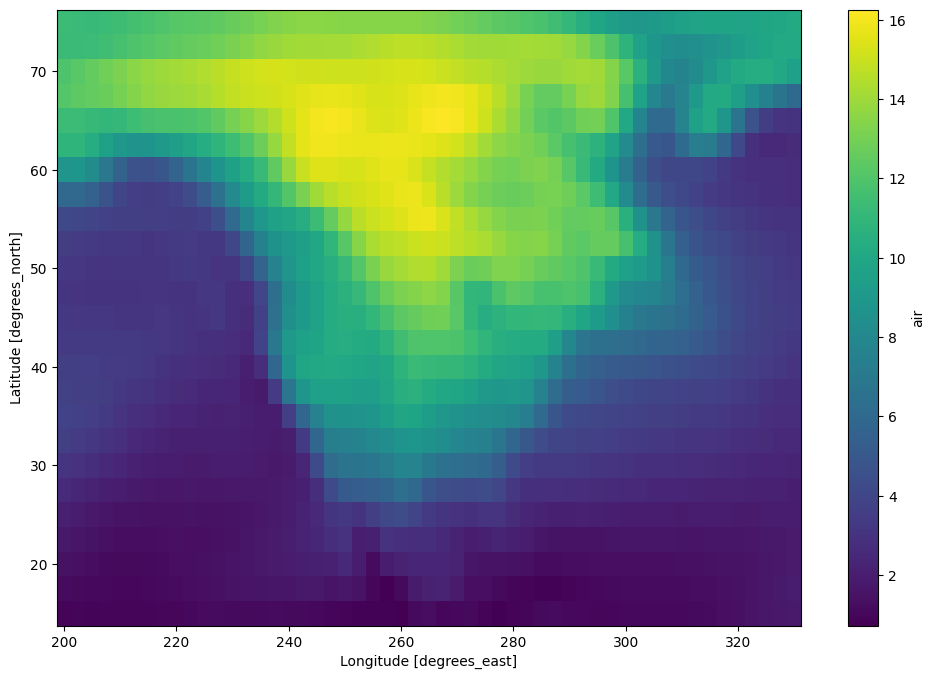

In [60]:
dair_resample.load().plot(figsize=(12, 8))

In [61]:
client.shutdown()